<a href="https://colab.research.google.com/github/JGradone/Topics-Sentinel/blob/main/Redwing_Real_Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topics in Marine Science: Redwing Real Time Data
*Written by Joe Gradone, Rutgers University, October 21, 2025*

## Getting Started

Jupyter notebooks have two kids of cells.  "Markdown" cells, like this one which can contain formatted text, and "Code" cells, which contain the code you will run.

To execute the code in a cell, you can either:
* click the **Play** icon on the left
* type **Cmd (or Ctrl) + Enter** to run the cell in place
* or type **Shift + Enter** to run the cell and move the focus to the next cell.

You can try all these options on our first very elaborate piece of code in the next cell.

After you execute the cell, the result will automatically display underneath the cell.

In [1]:
pip install erddapy


In [2]:
pip install cmocean

In [75]:
pip install gsw


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.7 MB/s eta 0:00:00


## Imports

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from erddapy import ERDDAP
import cmocean.cm as cmo
import netCDF4
import gsw


### This is a function to help with loading in glider data
def get_erddap_dataset(ds_id, server = 'https://slocum-data.marine.rutgers.edu/erddap/', variables=None, constraints=None, filetype='dataframe',protocol='tabledap'):
    ## Written by Mike Smith
    """
    Returns a netcdf dataset for a specified dataset ID (or dataframe if dataset cannot be converted to xarray)
    :param ds_id: dataset ID e.g. ng314-20200806T2040
    :param variables: optional list of variables
    :param constraints: optional list of constraints
    :param filetype: optional filetype to return, 'nc' (default) or 'dataframe'
    :return: netcdf dataset
    """
    variables = variables or None
    constraints = constraints or None
    filetype = filetype or 'nc'
    protocol = protocol or 'tabledap'

    e = ERDDAP(server,
               protocol=protocol,
               response='nc')
    e.dataset_id = ds_id
    if constraints:
        e.constraints = constraints
    if variables:
        e.variables = variables
    if filetype == 'nc':
        try:
            ds = e.to_xarray()
            ds = ds.sortby(ds.time)
        except OSError:
            print('No dataset available for specified constraints: {}'.format(ds_id))
            ds = []
        except TypeError:
            print('Cannot convert to xarray, providing dataframe: {}'.format(ds_id))
            ds = e.to_pandas().dropna()
    elif filetype == 'dataframe':
        #ds = e.to_pandas().dropna()
        ds = e.to_pandas().dropna(how='all')
    else:
        print('Unrecognized filetype: {}. Needs to  be "nc" or "dataframe"'.format(filetype))

    return ds



## Load data

We will load the glider data from this server: https://slocum-data.marine.rutgers.edu/erddap/

Here is the list of all of the specific variables for Redwing: https://slocum-data.marine.rutgers.edu/erddap/tabledap/redwing-20251011T1511-trajectory-raw-rt.html


In [83]:
## The specific ID for redwing
ds_id = 'redwing-20251011T1511-trajectory-raw-rt'
## Load flight data
variables = ['time', 'sci_water_temp', 'sci_water_pressure', 'sci_water_cond','latitude', 'longitude']
## Load the data
ds = get_erddap_dataset(ds_id, variables = variables)
## Change the name of the columns
ds.columns = variables
## Change the format of time variable
ds['time'] = pd.to_datetime(ds['time'], format='%Y-%m-%dT%H:%M:%SZ')
## Drop na
ds = ds.dropna().reset_index(drop=True)
## Sort dataset by time
ds = ds.sort_values(by='time')

## Convert salinity
ds['salinity'] = gsw.SP_from_C(ds['sci_water_cond']*10,ds['sci_water_temp'],ds['sci_water_pressure']*10)

## Print out the dataframe
ds

,time,sci_water_temp,sci_water_pressure,sci_water_cond,latitude,longitude,salinity
0,2025-10-11 15:11:18,0.0000,0.000,3.00000,40.857952,-70.436165,36.286455
1,2025-10-11 15:11:27,0.0000,0.000,3.00000,40.857967,-70.436164,36.286455
2,2025-10-11 15:12:51,16.9761,-0.053,4.16635,40.860540,-70.435967,32.212181
3,2025-10-11 15:13:52,16.9832,-0.043,4.16897,40.861310,-70.435885,32.229069
4,2025-10-11 15:14:53,16.9748,-0.052,4.16820,40.861423,-70.435840,32.229182
...,...,...,...,...,...,...,...
137467,2026-04-07 09:04:54,19.6763,-0.049,4.38577,32.132307,-34.307915,31.942002
137468,2026-04-07 09:05:07,19.6791,-0.056,4.38846,32.132307,-34.307915,31.961781
137469,2026-04-07 09:05:20,19.6773,-0.055,4.38536,32.132307,-34.307915,31.937923
137470,2026-04-07 09:05:33,19.6696,-0.057,4.38722,32.132307,-34.307915,31.958937


## Subset

In [84]:
redwing = ds.loc[ds['time'] > '2026-02-01'].sort_values(by='time')

redwing

,time,sci_water_temp,sci_water_pressure,sci_water_cond,latitude,longitude,salinity
137472,2026-02-26 14:39:42,19.3948,-0.050,4.31872,33.144638,-31.100450,31.609022
137473,2026-02-26 14:40:04,19.3922,-0.053,4.31811,33.144638,-31.100450,31.606015
137474,2026-02-26 14:40:17,19.3910,-0.050,4.31950,33.144638,-31.100450,31.618275
137475,2026-02-26 14:40:30,19.3921,-0.051,4.31806,33.144638,-31.100450,31.605675
137476,2026-02-26 14:40:43,19.3935,-0.052,4.12744,33.144638,-31.100450,30.052333
...,...,...,...,...,...,...,...
137467,2026-04-07 09:04:54,19.6763,-0.049,4.38577,32.132307,-34.307915,31.942002
137468,2026-04-07 09:05:07,19.6791,-0.056,4.38846,32.132307,-34.307915,31.961781
137469,2026-04-07 09:05:20,19.6773,-0.055,4.38536,32.132307,-34.307915,31.937923
137470,2026-04-07 09:05:33,19.6696,-0.057,4.38722,32.132307,-34.307915,31.958937


Text(0.5, 0, 'Time')

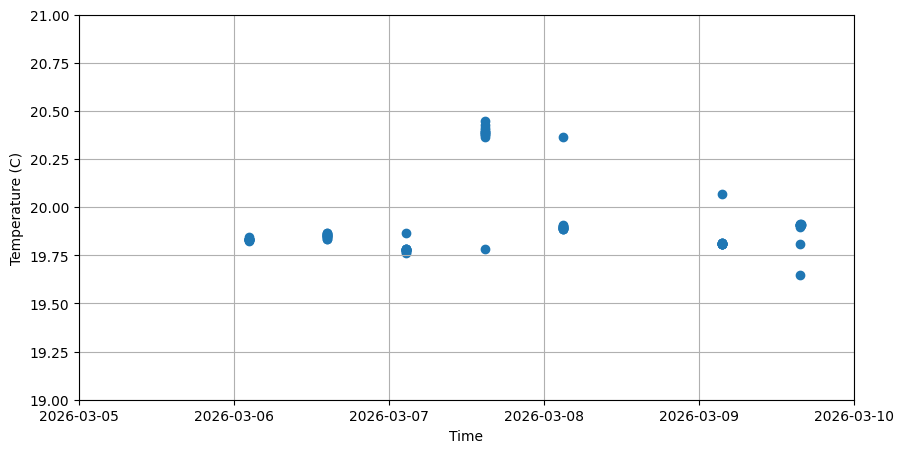

In [85]:
plt.figure(figsize=(10,5))
plt.scatter(redwing.time,redwing.sci_water_temp)
plt.ylim(19,21)
plt.xlim(pd.to_datetime('2026-03-05'),pd.to_datetime('2026-03-10'))
plt.grid()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')

Text(0, 0.5, 'Latitude')

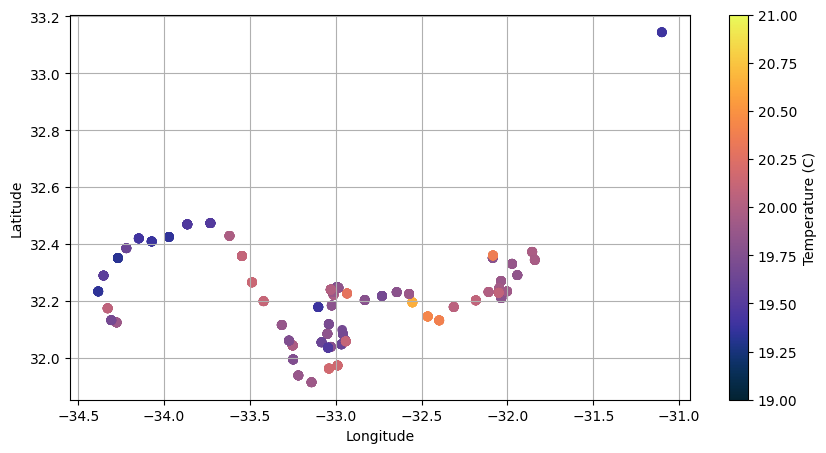

In [86]:
## Make figure
plt.figure(figsize=(10,5))
## Plot temp
plt.scatter(redwing.longitude,redwing.latitude,c=redwing.sci_water_temp,vmin=19,vmax=21,cmap=cmo.thermal)
# Make colorbar
plt.colorbar(label='Temperature (C)')
## Set limits
plt.grid()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

## Download Satellite Sea Surface Temperature data to compare with Redwing

Here is the server: https://coastwatch.pfeg.noaa.gov/erddap/griddap/nesdisVHNsstDaily.html

In [148]:
def get_sst(extent, tstart, tend):
    #dataset_id = 'nesdisVHNsstDaily'
    #variables = ['sea_surface_temperature']

    dataset_id = 'NOAA_DHW'
    variables = ['CRW_SST']



    lons = extent[:2]
    lats = extent[2:]
    e = ERDDAP(server='https://coastwatch.pfeg.noaa.gov/erddap/', protocol="griddap")
    e.dataset_id = dataset_id
    e.griddap_initialize()
    e.variables = list(variables)
    e.constraints["latitude<="]  = max(lats)
    e.constraints["latitude>="]  = min(lats)
    e.constraints["longitude<="] = max(lons)
    e.constraints["longitude>="] = min(lons)
    e.constraints["time>="] = tstart
    e.constraints["time<="] = tend

    return e.to_xarray()

# Example usage
extent = [-50, -40, 40, 50] # [lon min, lon max, lat min, lat max]
tstart = '2026-03-01'
tend   = '2026-04-06'

sst = get_sst(extent, tstart, tend)
#sst = sst.isel(altitude=0)
sst = sst.rename({'CRW_SST':'sst'})
sst

<xarray.Dataset> Size: 12MB
Dimensions:    (time: 36, latitude: 201, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 288B 2026-03-01T12:00:00 ... 2026-04-05T...
  * latitude   (latitude) float32 804B 50.03 49.97 49.92 ... 40.12 40.08 40.03
  * longitude  (longitude) float32 804B -49.97 -49.92 -49.88 ... -40.03 -39.97
Data variables:
    sst        (time, latitude, longitude) float64 12MB ...
Attributes: (12/63)
    acknowledgement:            NOAA Coral Reef Watch (CRW)
    cdm_data_type:              Grid
    comment:                    This product is designed to improve on and re...
    Conventions:                CF-1.6, ACDD-1.3
    creator_email:              coralreefwatch@noaa.gov
    creator_institution:        NOAA Coral Reef Watch (CRW)
    ...                         ...
    time_coverage_duration:     P1D
    time_coverage_end:          2026-04-05T12:00:00Z
    time_coverage_resolution:   P1D
    time_coverage_start:        2026-03-01T12:00:00Z
    title:                      NOAA Coral Reef Watch Operational Daily Near-...
    Westernmost_Easting:        -49.975

## Quick plot to make sure we like this dataset

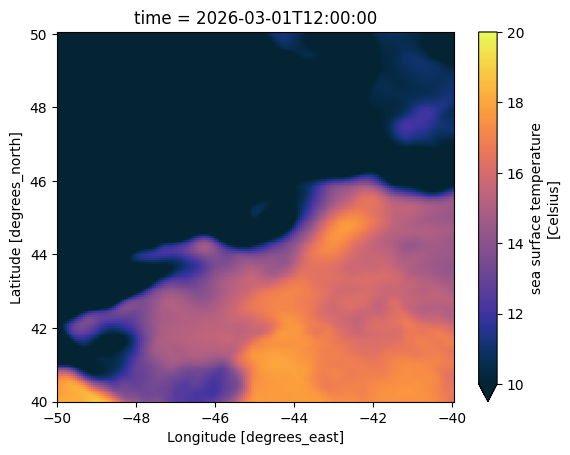

In [150]:
sst.sst.isel(time=0).plot(vmin=10,vmax=20,cmap=cmo.thermal)

In [151]:
# Function to get nearest SST for a single point
def get_nearest_sst(ds, lat, lon, time):
    # Select nearest in all three dimensions
    sst = ds['sst'].sel(
        latitude=lat,
        longitude=lon,
        time=time,
        method='nearest'
    )
    return float(sst.values)  # convert xarray.DataArray to scalar

# Apply to entire DataFrame
redwing['matched_sst'] = redwing.apply(lambda row: get_nearest_sst(sst, row['latitude'], row['longitude'], row['time']), axis=1)
redwing


,time,sci_water_temp,sci_water_pressure,sci_water_cond,latitude,longitude,salinity,matched_sst
137472,2026-02-26 14:39:42,19.3948,-0.050,4.31872,33.144638,-31.100450,31.609022,16.40
137473,2026-02-26 14:40:04,19.3922,-0.053,4.31811,33.144638,-31.100450,31.606015,16.40
137474,2026-02-26 14:40:17,19.3910,-0.050,4.31950,33.144638,-31.100450,31.618275,16.40
137475,2026-02-26 14:40:30,19.3921,-0.051,4.31806,33.144638,-31.100450,31.605675,16.40
137476,2026-02-26 14:40:43,19.3935,-0.052,4.12744,33.144638,-31.100450,30.052333,16.40
...,...,...,...,...,...,...,...,...
137467,2026-04-07 09:04:54,19.6763,-0.049,4.38577,32.132307,-34.307915,31.942002,17.52
137468,2026-04-07 09:05:07,19.6791,-0.056,4.38846,32.132307,-34.307915,31.961781,17.52
137469,2026-04-07 09:05:20,19.6773,-0.055,4.38536,32.132307,-34.307915,31.937923,17.52
137470,2026-04-07 09:05:33,19.6696,-0.057,4.38722,32.132307,-34.307915,31.958937,17.52


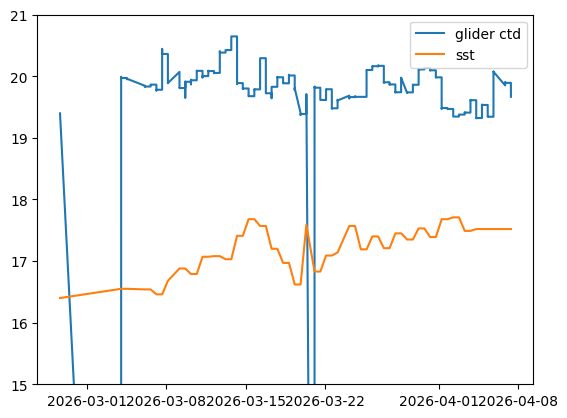

In [152]:
plt.plot(redwing.time,redwing.sci_water_temp,label='glider ctd')
plt.plot(redwing.time,redwing.matched_sst,label='sst')
plt.ylim(15,21)
plt.legend()

## SST Group: Make this plot pretty and add your interpretation!

## Pick out dive and climb

In [88]:
### This range is the full dive and climb-CTD on record
#start_time = pd.to_datetime('2025-10-16T10:00:00')
#end_time = pd.to_datetime('2025-10-18')

##
start_time = pd.to_datetime('2025-10-17T16:50:00')
end_time = pd.to_datetime('2025-10-18')

## Pull out dive and climb
redwing_dc = ds.loc[(ds['time'] > start_time) & (ds['time'] < end_time)].sort_values(by='time')
redwing_dc


,time,sci_water_temp,sci_water_pressure,sci_water_cond,latitude,longitude,salinity
15652,2025-10-17 16:51:12,17.4087,0.287,4.33157,39.784542,-70.442320,33.282486
15653,2025-10-17 16:52:33,17.3990,-0.004,4.33017,39.784271,-70.443437,33.279498
15654,2025-10-17 16:52:46,17.4034,0.030,4.33024,39.784267,-70.443454,33.276359
15655,2025-10-17 16:52:59,17.3988,0.060,3.52770,39.784264,-70.443471,26.492955
15656,2025-10-17 16:53:12,17.3982,0.078,4.33045,39.784260,-70.443488,33.282261
...,...,...,...,...,...,...,...
16400,2025-10-17 19:34:23,17.5153,0.472,4.34581,39.784293,-70.445337,33.316403
16401,2025-10-17 19:34:36,17.5111,0.329,4.34515,39.784293,-70.445339,33.314719
16402,2025-10-17 19:34:49,17.5130,0.170,4.34573,39.784293,-70.445342,33.318711
16403,2025-10-17 19:35:02,17.5054,0.166,4.34550,39.784293,-70.445344,33.322999


(1000.0, -5.0)

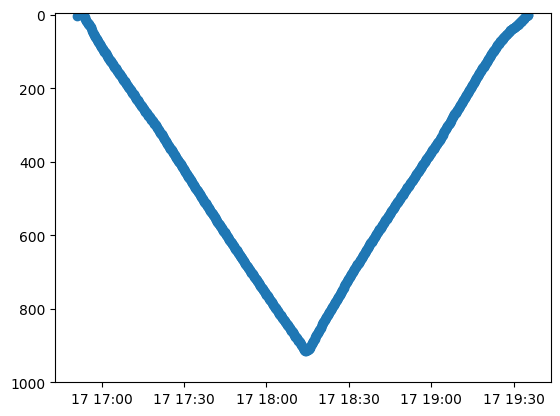

In [89]:
plt.scatter(redwing_dc.time,redwing_dc.sci_water_pressure*10) ## convert bar to depth, approximately
plt.ylim(1000,-5)

In [90]:
# Find the index of maximum pressure
max_idx = redwing_dc['sci_water_pressure'].idxmax()

# Slice the dive and climb
dive = redwing_dc.loc[:max_idx]
climb = redwing_dc.loc[max_idx:]

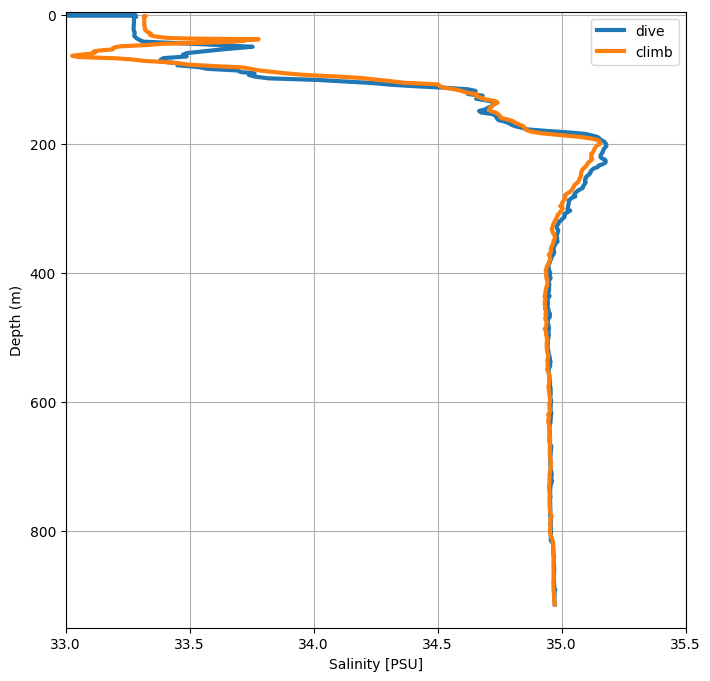

In [101]:
plt.figure(figsize=(8,8))
plt.plot(dive.salinity,dive.sci_water_pressure*10,linewidth=3,label='dive')
plt.plot(climb.salinity,climb.sci_water_pressure*10,linewidth=3,label='climb')
plt.grid()
plt.ylim(950,-5)
plt.xlim(33,35.5)
plt.ylabel('Depth (m)')
plt.xlabel('Salinity [PSU]')
plt.legend()

# Dive/Climb group: Now you guys do the same with other dive-climb pairs to evaluate if there is any thermal lag!